In [1]:
pip install imbalanced-learn

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
print("--- 1. NẠP DỮ LIỆU VÀ TIỀN XỬ LÝ ĐẶC TRƯNG ---")
# Nạp dữ liệu từ giai đoạn DWH/Tiền xử lý (Ví dụ file của tháng 10)
df = pd.read_csv('2019-Oct-Cleaned.csv')

# 1. Trích xuất đặc trưng thời gian từ cột event_time (nếu chưa có)
if 'event_time' in df.columns:
    # Chuyển đổi sang kiểu datetime (bỏ qua timezone để xử lý nhanh hơn nếu cần)
    df['event_time'] = pd.to_datetime(df['event_time'].str.replace(' UTC', ''), errors='coerce')
    df['hour'] = df['event_time'].dt.hour
    df['day_of_week'] = df['event_time'].dt.dayofweek
else:
    # Dự phòng nếu file đã tách sẵn cột nhưng đặt tên khác
    if 'hour' not in df.columns:
        df['hour'] = 0  # Giá trị mặc định nếu hoàn toàn không tìm thấy dữ liệu thời gian
    if 'day_of_week' not in df.columns:
        df['day_of_week'] = 0

# 2. Định nghĩa Target (y): 1 là purchase, 0 là các hành vi khác
df['is_purchase'] = (df['event_type'] == 'purchase').astype(int)

# 3. Mã hóa Label Encoding cho các cột phân loại (Categorical)
# Thay vì gọi từ file có sẵn đuôi _encoded, ta tự encode trực tiếp ở đây
categorical_cols = {
    'day_of_week': 'day_of_week_encoded',
    'brand': 'brand_encoded',
    'category_code': 'category_code_encoded'
}

for col, encoded_col in categorical_cols.items():
    if col in df.columns:
        # Ép kiểu về chuỗi và mã hóa bằng phương thức factorize của pandas (nhanh và tiện)
        df[encoded_col] = df[col].astype(str).factorize()[0]
    else:
        # Nếu không có cột gốc, tạo cột chứa giá trị 0 mặc định để tránh crash
        print(f"Cảnh báo: Không tìm thấy cột '{col}', tạo cột giả lập.")
        df[encoded_col] = 0

# Lựa chọn Features (X) sau khi đã đảm bảo các cột tồn tại
features = ['price', 'hour', 'day_of_week_encoded', 'brand_encoded', 'category_code_encoded']

# Đảm bảo cột 'price' không bị rỗng
if 'price' in df.columns:
    df['price'] = df['price'].fillna(df['price'].median())

X = df[features]
y = df['is_purchase']

print(f"Kích thước tập dữ liệu: {df.shape}")
print(f"Phân phối nhãn trước xử lý:\n{y.value_counts(normalize=True) * 100}")

--- 1. NẠP DỮ LIỆU VÀ TIỀN XỬ LÝ ĐẶC TRƯNG ---
Kích thước tập dữ liệu: (42418544, 15)
Phân phối nhãn trước xử lý:
0    98.248943
1     1.751057
Name: is_purchase, dtype: float64


In [5]:
print("--- 2. CHIA TẬP TRAIN/TEST VÀ CHUẨN HÓA ---")
# Chia tập dữ liệu (80/20) với tham số stratify để giữ tỷ lệ nhãn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuẩn hóa dữ liệu (Scaling) - Rất quan trọng đối với thuật toán SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- 3. ÁP DỤNG SMOTE CHO TẬP TRAIN ---")
# Cân bằng dữ liệu do lượng 'purchase' rất nhỏ
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Kích thước tập Train sau SMOTE: {X_train_resampled.shape}")

# Giải phóng RAM
del df, X, y, X_train, X_train_scaled
gc.collect()

--- 2. CHIA TẬP TRAIN/TEST VÀ CHUẨN HÓA ---
--- 3. ÁP DỤNG SMOTE CHO TẬP TRAIN ---
Kích thước tập Train sau SMOTE: (66681234, 5)


28

In [6]:
print("--- 4A. HUẤN LUYỆN MÔ HÌNH SVM (LinearSVC) ---")
# Khởi tạo và huấn luyện SVM
svm_model = LinearSVC(random_state=42, class_weight='balanced', dual=False)
svm_model.fit(X_train_resampled, y_train_resampled)

# Dự đoán trên tập Test
y_pred_svm = svm_model.predict(X_test_scaled)

print("Hoàn tất huấn luyện SVM!")

--- 4A. HUẤN LUYỆN MÔ HÌNH SVM (LinearSVC) ---
Hoàn tất huấn luyện SVM!


In [7]:
print("--- 4B. HUẤN LUYỆN MÔ HÌNH NAIVE BAYES ---")
# Khởi tạo và huấn luyện Naive Bayes (GaussianNB phù hợp cho dữ liệu liên tục đã qua xử lý)
nb_model = GaussianNB()
nb_model.fit(X_train_resampled, y_train_resampled)

# Dự đoán trên tập Test
y_pred_nb = nb_model.predict(X_test_scaled)

print("Hoàn tất huấn luyện Naive Bayes!")

--- 4B. HUẤN LUYỆN MÔ HÌNH NAIVE BAYES ---
Hoàn tất huấn luyện Naive Bayes!


--- 5. ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH ---
\n========================================
KẾT QUẢ ĐÁNH GIÁ: Support Vector Machine (LinearSVC)
\n1. Classification Report:


              precision    recall  f1-score   support

           0       0.99      0.51      0.67   8335154
           1       0.02      0.65      0.04    148555

    accuracy                           0.51   8483709
   macro avg       0.51      0.58      0.36   8483709
weighted avg       0.97      0.51      0.66   8483709



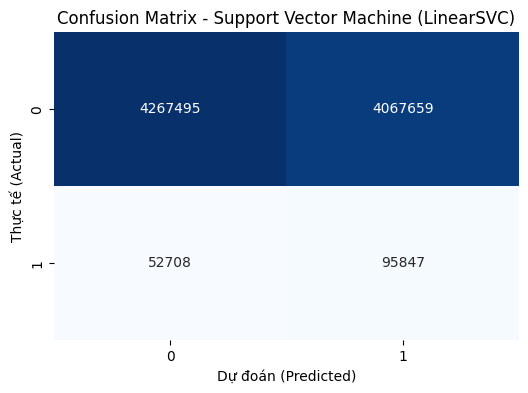

\n========================================
KẾT QUẢ ĐÁNH GIÁ: Naive Bayes (GaussianNB)
\n1. Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.23      0.38   8335154
           1       0.02      0.87      0.04    148555

    accuracy                           0.24   8483709
   macro avg       0.50      0.55      0.21   8483709
weighted avg       0.97      0.24      0.37   8483709



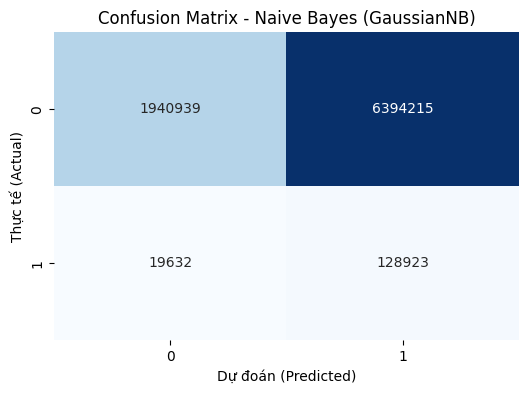

In [8]:
print("--- 5. ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH ---")

def evaluate_model(y_true, y_pred, model_name):
    print(f"\\n{'='*40}")
    print(f"KẾT QUẢ ĐÁNH GIÁ: {model_name}")
    print(f"{'='*40}")
    
    # In báo cáo phân loại (Precision, Recall, F1-Score)
    print("\\n1. Classification Report:")
    print(classification_report(y_true, y_pred))
    
    # Vẽ Confusion Matrix trực quan
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế (Actual)')
    plt.xlabel('Dự đoán (Predicted)')
    plt.show()

# Đánh giá SVM
evaluate_model(y_test, y_pred_svm, "Support Vector Machine (LinearSVC)")

# Đánh giá Naive Bayes
evaluate_model(y_test, y_pred_nb, "Naive Bayes (GaussianNB)")